In [1]:
import base64, io, traceback
from typing import Optional
import numpy as np
import torch
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image
from pydantic import BaseModel
from transformers import ViTImageProcessor, ViTForImageClassification

c:\Users\JMZ\.conda\envs\ml_stable\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── PDF support (PyMuPDF preferred, pdf2image fallback) ───────────────────────
try:
    import fitz
    def pdf_to_images(raw: bytes):
        doc = fitz.open(stream=raw, filetype="pdf")
        return [Image.frombytes("RGB", [p.width, p.height], p.samples)
                for pg in doc for p in [pg.get_pixmap(matrix=fitz.Matrix(150/72, 150/72))]]
except ImportError:
    try:
        from pdf2image import convert_from_bytes
        def pdf_to_images(raw: bytes): return convert_from_bytes(raw, dpi=150)
    except ImportError:
        def pdf_to_images(_): raise HTTPException(503, "No PDF backend. Run: pip install pymupdf")

In [3]:
with open("fish.pdf", "rb") as f:
    pdf_bytes = f.read()
images = pdf_to_images(pdf_bytes)

In [4]:
print("Cplor mode:", images[0].mode)       # e.g. RGB
print("size:", images[0].size)  # e.g. (1275, 1650)
print("width:", images[0].width)          # e.g. 1275
print("height:", images[0].height)         # e.g. 1650
print("format:", images[0].format)     # None for in-memory images

Cplor mode: RGB
size: (2134, 2134)
width: 2134
height: 2134
format: None


In [5]:
# Hugging Face ViTForImageClassification + PyTorch: use output_attentions for attention, processor for preprocessing
class ViT:
    def __init__(self, model_name_or_path="vit"):
        self.processor = ViTImageProcessor.from_pretrained(model_name_or_path, local_files_only=True)
        self.model = ViTForImageClassification.from_pretrained(model_name_or_path, local_files_only=True, attn_implementation="eager")
        self.model.config.output_attentions = True
        self.model.eval()
        cfg = self.model.config
        self.num_heads = cfg.num_attention_heads
        self.num_layers = cfg.num_hidden_layers
        # seq_len = (image_size // patch_size)^2 + 1 (CLS); grid used to reshape attention into spatial heatmap
        patch_size = cfg.patch_size if isinstance(cfg.patch_size, int) else cfg.patch_size[0]
        img_size = cfg.image_size if isinstance(cfg.image_size, int) else cfg.image_size[0]
        self.grid = img_size // patch_size  # 14 for 224/16
        # ImageNet index -> class name (from config.id2label)
        self.id2label = getattr(cfg, "id2label", None) or {}
        self._attn = {}  # after each run: layer index -> (H, N, N) numpy

    @torch.no_grad()
    def run(self, img: Image.Image):
        """Run forward pass and store per-layer attention (HF returns attentions as tuple of (1, H, N, N) per layer)."""
        inputs = self.processor(images=img.convert("RGB"), return_tensors="pt")
        pixel_values = inputs["pixel_values"]
        device = next(self.model.parameters()).device
        pixel_values = pixel_values.to(device)
        outputs = self.model(pixel_values, output_attentions=True, return_dict=True)
        if isinstance(outputs, tuple):
            # return_dict=False: (logits, hidden_states?, attentions)
            attentions = outputs[-1] if len(outputs) > 1 else None
        else:
            attentions = getattr(outputs, "attentions", None)
        if not attentions or len(attentions) == 0:
            raise RuntimeError(
                "Model returned no attention weights. Ensure the model supports output_attentions=True."
            )

        # attentions: tuple of (batch, num_heads, seq_len, seq_len); take batch=0 -> (H, N, N)
        self._attn = {
            i: attn[0].detach().cpu().numpy()
            for i, attn in enumerate(attentions)
        }
        logits = outputs.logits[0]
        probs = torch.softmax(logits, dim=0)
        top5v, top5i = probs.topk(5)
        def _label(idx: int):
            return self.id2label.get(idx, f"class_{idx}")
        return [(int(i.item()), float(p.item()), _label(int(i.item()))) for i, p in zip(top5i, top5v)]

    def _norm(self, x):
        x = np.asarray(x, dtype=np.float64)
        mn, mx = x.min(), x.max()
        return (x - mn) / (mx - mn + 1e-8)

    def cls_attn(self, layer=-1, head=None):
        """CLS token attention over patches; optional layer and head, or mean over heads."""
        if not self._attn:
            raise RuntimeError("No attention data. Call vit.run(img) first for the image to analyze.")
        a = self._attn[layer % self.num_layers]  # (H, N, N)
        row = a[:, 0, 1:]  # (H, num_patches), drop CLS->CLS, keep CLS->patches only
        w = row.mean(0) if head is None else row[head]
        return self._norm(w.reshape(self.grid, self.grid))

    def rollout(self):
        """Attention rollout (Abnar & Zuidema 2020)."""
        if not self._attn:
            raise RuntimeError("No attention data. Call vit.run(img) first for the image to analyze.")
        N = self._attn[0].shape[-1]
        r = np.eye(N, dtype=np.float64)
        for i in range(self.num_layers):
            A = self._attn[i].mean(0) + np.eye(N)
            A = A / (A.sum(axis=-1, keepdims=True) + 1e-8)
            r = A @ r
        return self._norm(r[0, 1:].reshape(self.grid, self.grid))

    def all_layers(self):
        if not self._attn:
            raise RuntimeError("No attention data. Call vit.run(img) first for the image to analyze.")
        return self._norm(np.mean([self.cls_attn(l) for l in range(self.num_layers)], axis=0))

    def to_grid(self, hm, size=20):
        arr = np.array(Image.fromarray((np.clip(hm, 0, 1) * 255).astype(np.uint8)).resize((size, size), Image.BILINEAR)) / 255.0
        return np.clip(arr + np.random.uniform(0, 0.015, arr.shape), 0, 1).tolist()


In [6]:
# Local runner: same interface as the API (no FastAPI), for in-notebook use
class LocalViTAnalyzer:
    """Runs the same logic as /api/analyze-image and /api/analyze-pdf locally."""

    def __init__(self, model_name_or_path: str = "vit"):
        self.vit = ViT(model_name_or_path=model_name_or_path)

    def _decode_b64(self, s: str) -> bytes:
        s = s.split(",", 1)[-1]
        return base64.b64decode(s + "=" * (-len(s) % 4))

    def _analyze(self, img: Image.Image, layer: int, head: Optional[int], mode: str):
        top5 = self.vit.run(img)
        hm = {"rollout": self.vit.rollout, "all_layers": self.vit.all_layers}.get(
            mode, lambda: self.vit.cls_attn(layer, head)
        )()
        return self.vit.to_grid(hm), top5

    def analyze_image(
        self,
        base64_data: str,
        layer: int = -1,
        head: Optional[int] = None,
        mode: str = "cls",
    ):
        """Same response shape as POST /api/analyze-image."""
        img = Image.open(io.BytesIO(self._decode_b64(base64_data))).convert("RGB")
        hm, top5 = self._analyze(img, layer, head, mode)
        return {
            "success": True,
            "heatmaps": [{"page": 1, "heatmap": hm, "top5": top5}],
            "pageCount": 1,
        }

    def analyze_pdf(
        self,
        base64_data: str,
        layer: int = -1,
        head: Optional[int] = None,
        mode: str = "cls",
    ):
        """Same response shape as POST /api/analyze-pdf."""
        pages = pdf_to_images(self._decode_b64(base64_data))
        out = []
        for i, pg in enumerate(pages, 1):
            hm, top5 = self._analyze(pg, layer, head, mode)
            out.append({"page": i, "heatmap": hm, "top5": top5})
        return {"success": True, "heatmaps": out, "pageCount": len(out), "mode": mode}

    def analyze_pil(self, img: Image.Image, layer: int = -1, head: Optional[int] = None, mode: str = "cls"):
        """Convenience: run on a PIL Image and return heatmap array + top5 (for visualization)."""
        top5 = self.vit.run(img)
        hm = {"rollout": self.vit.rollout, "all_layers": self.vit.all_layers}.get(
            mode, lambda: self.vit.cls_attn(layer, head)
        )()
        return np.array(hm), top5

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 746.42it/s, Materializing param=vit.layernorm.weight]                                 


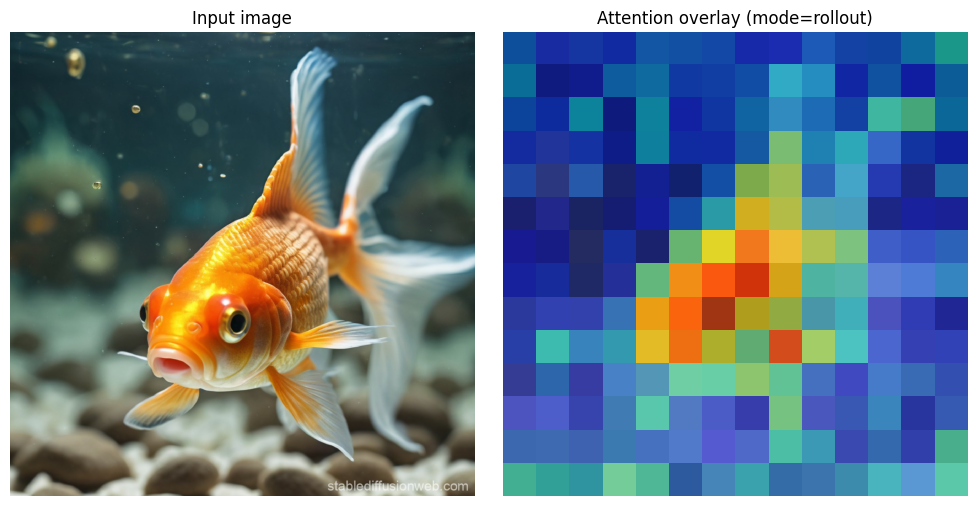

Top-5 (index, probability, class name):
  1: 0.9993 — goldfish, Carassius auratus
  973: 0.0001 — coral reef
  0: 0.0001 — tench, Tinca tinca
  393: 0.0000 — anemone fish
  392: 0.0000 — rock beauty, Holocanthus tricolor


In [7]:
# Visualize attention: run local analyzer and overlay heatmap on image
import matplotlib.pyplot as plt

# Image source: use images[0] from PDF cell if available, else load file, else placeholder
try:
    img = images[0]
except NameError:
    try:
        img = Image.open("image.jpg").convert("RGB")
    except FileNotFoundError:
        img = Image.new("RGB", (224, 224), (128, 128, 128))

analyzer = LocalViTAnalyzer(model_name_or_path="vit")
# Get raw heatmap (2D array) and top5 for plotting; mode: "cls" | "rollout" | "all_layers"
heatmap_arr, top5 = analyzer.analyze_pil(img, layer=-1, head=None, mode="rollout")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: original image
axes[0].imshow(img)
axes[0].set_title("Input image")
axes[0].axis("off")

# Right: overlay heatmap on resized image (same aspect as heatmap grid)
img_small = img.resize((heatmap_arr.shape[1], heatmap_arr.shape[0]), Image.BILINEAR)
axes[1].imshow(img_small)
axes[1].imshow(heatmap_arr, cmap="jet", alpha=0.5)
axes[1].set_title("Attention overlay (mode=rollout)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Print top-5 predictions (class index, probability, ImageNet class name)
print("Top-5 (index, probability, class name):")
for idx, prob, name in top5:
    print(f"  {idx}: {prob:.4f} — {name}")

### The code below is for future api development, ignore them now.

In [22]:
app = FastAPI(title="ViT Heatmap API")
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])
vit: Optional[ViT] = None

@app.on_event("startup")
def startup(): global vit; vit = ViT()

class Req(BaseModel):
    base64Data: str
    layer: int = -1
    head: Optional[int] = None
    mode: str = "cls"   # cls | rollout | all_layers

def decode_b64(s: str) -> bytes:
    s = s.split(",", 1)[-1]
    return base64.b64decode(s + "=" * (-len(s) % 4))

def analyze(img: Image.Image, req: Req):
    top5 = vit.run(img)
    hm   = {"rollout": vit.rollout, "all_layers": vit.all_layers}.get(req.mode, lambda: vit.cls_attn(req.layer, req.head))()
    return vit.to_grid(hm), top5

@app.post("/api/analyze-image")
async def analyze_image(req: Req):
    img = Image.open(io.BytesIO(decode_b64(req.base64Data))).convert("RGB")
    hm, top5 = analyze(img, req)
    return {"success": True, "heatmaps": [{"page": 1, "heatmap": hm, "top5": top5}], "pageCount": 1}

@app.post("/api/analyze-pdf")
async def analyze_pdf(req: Req):
    pages = pdf_to_images(decode_b64(req.base64Data))
    out   = [{"page": i, "heatmap": hm, "top5": top5}
             for i, pg in enumerate(pages, 1)
             for hm, top5 in [analyze(pg, req)]]
    return {"success": True, "heatmaps": out, "pageCount": len(out), "mode": req.mode}

C:\Users\JMZ\AppData\Local\Temp\ipykernel_15704\577370458.py:5: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app.on_event("startup")
